# Model Training
Dish to Recipe — Cross-Modal Retrieval

Fine-tunes CLIP-ViT-L/14 adapter layers using InfoNCE contrastive loss on food-recipe pairs.
Expected training time: ~1 hour on a good GPU.

## Step 1 — Install Dependencies

In [1]:
!uv add open_clip_torch torch torchvision pillow tqdm -q

## Step 2 — Imports & Device Setup

In [2]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import open_clip
from tqdm import tqdm
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

/home/s22imc10262/data/NLP/hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA L40S
VRAM: 47.7 GB


## Step 3 — Load CLIP Model

In [3]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-L-14', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-L-14')
model = model.to(device)

# Freeze all base CLIP weights
for param in model.parameters():
    param.requires_grad = False

print('CLIP-ViT-L/14 loaded and frozen')

/home/s22imc10262/data/NLP/hackathon/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP-ViT-L/14 loaded and frozen


## Step 4 — Define Adapter Layers
Small MLP adapters added on top of CLIP's frozen image and text encoders.
Only these layers are trained — keeps training fast and stable.

In [4]:
class Adapter(nn.Module):
    def __init__(self, dim=768, bottleneck=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, dim)
        )
        # Init as near-identity so training starts stable
        nn.init.zeros_(self.net[2].weight)
        nn.init.zeros_(self.net[2].bias)

    def forward(self, x):
        return x + self.net(x)  # residual connection

image_adapter = Adapter(dim=768).to(device)
text_adapter  = Adapter(dim=768).to(device)

# Learnable temperature
log_temperature = nn.Parameter(torch.tensor(0.07).log())

trainable_params = (
    list(image_adapter.parameters()) +
    list(text_adapter.parameters()) +
    [log_temperature]
)

total = sum(p.numel() for p in trainable_params)
print(f'Trainable parameters: {total:,}')

Trainable parameters: 788,481


## Step 5 — Dataset Class

In [8]:
class FoodRecipeDataset(Dataset):
    def __init__(self, json_path, preprocess, tokenizer, max_ingredients=10):
        with open(json_path) as f:
            self.data = json.load(f)
        self.preprocess = preprocess
        self.tokenizer = tokenizer
        self.max_ingredients = max_ingredients

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Load and preprocess image
        img = Image.open(item['image_path']).convert('RGB')
        img_tensor = self.preprocess(img)

        # Build text: "<recipe name>: ingredient1, ingredient2, ..."
        ingredients = item['ingredients'][:self.max_ingredients]
        text = f"{item['recipe_name']}: {', '.join(ingredients)}"

        # Tokenize (CLIP truncates at 77 tokens automatically)
        text_tensor = self.tokenizer([text])[0]

        return img_tensor, text_tensor


dataset = FoodRecipeDataset('./data/paired_dataset.json', preprocess, tokenizer)
print(f'Dataset size: {len(dataset)} pairs')

# Sample check
img_t, txt_t = dataset[0]
print(f'Image tensor shape: {img_t.shape}')
print(f'Text tensor shape:  {txt_t.shape}')

Dataset size: 5000 pairs
Image tensor shape: torch.Size([3, 224, 224])
Text tensor shape:  torch.Size([77])


## Step 6 — DataLoader
Adjust batch_size based on your VRAM. 256 needs ~16GB, 128 needs ~10GB, 64 needs ~6GB.

In [17]:
BATCH_SIZE = 512
NUM_EPOCHS = 40
LR = 1e-4

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f'Batches per epoch: {len(loader)}')
print(f'Total steps: {len(loader) * NUM_EPOCHS}')

Batches per epoch: 10
Total steps: 400


## Step 7 — InfoNCE Loss Function

In [18]:
def infonce_loss(image_embeds, text_embeds, log_temp):
    # Normalize embeddings
    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds  = F.normalize(text_embeds,  dim=-1)

    # Similarity matrix: [batch x batch]
    temperature = log_temp.exp().clamp(min=0.01, max=100)
    logits = (image_embeds @ text_embeds.T) / temperature

    # Diagonal = correct pairs
    labels = torch.arange(len(logits), device=logits.device)

    # Symmetric loss: image→text and text→image
    loss_i2t = F.cross_entropy(logits,   labels)
    loss_t2i = F.cross_entropy(logits.T, labels)

    return (loss_i2t + loss_t2i) / 2

## Step 8 — Training Loop

In [ ]:
os.makedirs('checkpoints', exist_ok=True)
best_loss = float('inf')
loss_history = []

model.eval()  # CLIP stays in eval (frozen)
image_adapter.train()
text_adapter.train()

patience = 5
min_delta = 0.05
no_improve_count = 0

# Resume from checkpoint
checkpoint = torch.load('checkpoints/best_model.pt', map_location=device)
image_adapter.load_state_dict(checkpoint['image_adapter'])
text_adapter.load_state_dict(checkpoint['text_adapter'])
log_temperature.data = checkpoint['log_temperature']
start_epoch = checkpoint['epoch'] + 1
print(f'Resuming from epoch {start_epoch}')

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_losses = []

    for images, texts in tqdm(loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
        images = images.to(device)
        texts  = texts.to(device)

        with torch.no_grad():
            image_feats = model.encode_image(images).float()
            text_feats  = model.encode_text(texts).float()

        # Pass through adapters
        image_embeds = image_adapter(image_feats)
        text_embeds  = text_adapter(text_feats)

        loss = infonce_loss(image_embeds, text_embeds, log_temperature)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    scheduler.step()
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1} — avg loss: {avg_loss:.4f} | temp: {log_temperature.exp().item():.4f}')

    # Save best checkpoint
    if avg_loss < best_loss - min_delta:
        best_loss = avg_loss
        no_improve_count = 0
        torch.save({
            'image_adapter': image_adapter.state_dict(),
            'text_adapter':  text_adapter.state_dict(),
            'log_temperature': log_temperature.data,
            'epoch': epoch
        }, 'checkpoints/best_model.pt')
        print(f'  ✓ Saved best checkpoint')
    else:
        no_improve_count += 1
        print(f'  No improvement ({no_improve_count}/{patience})')
        if no_improve_count >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'\nTraining complete. Best loss: {best_loss:.4f}')

Resuming from epoch 20


Epoch 21/40: 100%|██████████| 10/10 [00:35<00:00,  3.56s/it]


Epoch 21 — avg loss: 3.2164 | temp: 0.0690
  ✓ Saved best checkpoint


Epoch 22/40: 100%|██████████| 10/10 [00:36<00:00,  3.61s/it]


Epoch 22 — avg loss: 3.1761 | temp: 0.0690
  No improvement (1/5)


...

Epoch 27/40: 100%|██████████| 10/10 [00:38<00:00,  3.85s/it]


Epoch 27 — avg loss: 3.0526 | temp: 0.0687
  No improvement (1/5)


Epoch 28/40: 100%|██████████| 10/10 [00:38<00:00,  3.85s/it]


Epoch 28 — avg loss: 3.0346 | temp: 0.0686
  No improvement (2/5)


Epoch 29/40:  50%|█████     | 5/10 [00:21<00:19,  3.91s/it]

## Step 9 — Plot Training Loss

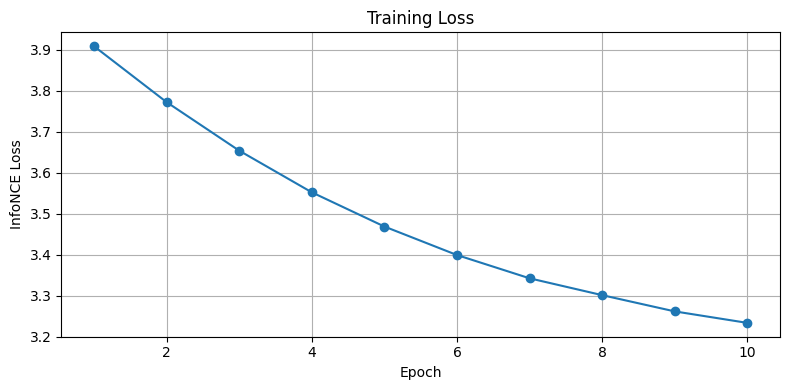

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=100)
plt.show()

## Step 10 — Pre-compute Recipe Index
Embeds all recipes from Food.com and saves to disk.
This only needs to run once — the index is reused at inference time.

In [ ]:
import pandas as pd
import ast

# Load best checkpoint
checkpoint = torch.load('checkpoints/best_model.pt', map_location=device)
image_adapter.load_state_dict(checkpoint['image_adapter'])
text_adapter.load_state_dict(checkpoint['text_adapter'])
log_temperature.data = checkpoint['log_temperature']
image_adapter.eval()
text_adapter.eval()

# Load Food.com recipes
recipes_df = pd.read_csv('RAW_recipes.csv')
recipes_df['ingredients'] = recipes_df['ingredients'].apply(ast.literal_eval)
recipes_df = recipes_df[['name', 'ingredients', 'id']].dropna()

# Limit to 50k for speed — increase if you have RAM
recipes_df = recipes_df.sample(150000, random_state=42).reset_index(drop=True)
print(f'Indexing {len(recipes_df)} recipes...')

all_embeddings = []
EMBED_BATCH = 1024

with torch.no_grad():
    for i in tqdm(range(0, len(recipes_df), EMBED_BATCH)):
        batch = recipes_df.iloc[i:i+EMBED_BATCH]
        texts = [
            f"{row['name']}: {', '.join(row['ingredients'][:10])}"
            for _, row in batch.iterrows()
        ]
        tokens = tokenizer(texts).to(device)
        feats  = model.encode_text(tokens).float()
        embeds = text_adapter(feats)
        embeds = F.normalize(embeds, dim=-1)
        all_embeddings.append(embeds.cpu().numpy())

recipe_index = np.vstack(all_embeddings)
np.save('recipe_index.npy', recipe_index)
recipes_df.to_csv('recipe_index_metadata.csv', index=False)

print(f'Index saved: {recipe_index.shape}')  # (50000, 768)

## Step 11 — Quick Retrieval Test
Sanity check: query with a Food101 image and see if the top-3 results make sense.

In [ ]:
# Step 11 — Retrieval Test on New Images
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

NEW_IMAGES_FOLDER = './test_images'  # drop your new images here
os.makedirs(NEW_IMAGES_FOLDER, exist_ok=True)

def retrieve(image_path, k=3):
    img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feats  = model.encode_image(img_tensor).float()
        embeds = image_adapter(feats)
        embeds = F.normalize(embeds, dim=-1).cpu().numpy()

    scores = (recipe_index @ embeds.T).squeeze()
    top_k  = np.argsort(scores)[::-1][:k]

    results = []
    for idx in top_k:
        row = recipes_df.iloc[idx]
        results.append({
            'recipe':      row['name'],
            'ingredients': row['ingredients'][:8],
            'score':       float(scores[idx])
        })
    return results


# Find all images in the folder
image_files = [
    f for f in os.listdir(NEW_IMAGES_FOLDER)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
]

if len(image_files) == 0:
    print(f'No images found in {NEW_IMAGES_FOLDER}. Add some JPG/PNG images and re-run.')
else:
    for image_file in image_files:
        image_path = os.path.join(NEW_IMAGES_FOLDER, image_file)
        results = retrieve(image_path, k=3)

        # Plot image + results side by side
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Left: query image
        axes[0].imshow(mpimg.imread(image_path))
        axes[0].set_title(f'Query: {image_file}', fontsize=10)
        axes[0].axis('off')

        # Right: top-3 results as text
        result_text = ''
        for i, r in enumerate(results):
            ingredients_str = ', '.join(r['ingredients'][:5])
            result_text += f"#{i+1} {r['recipe'].title()} (score: {r['score']:.3f})\n"
            result_text += f"     {ingredients_str}\n\n"

        axes[1].text(0.05, 0.95, result_text, transform=axes[1].transAxes,
                     fontsize=9, verticalalignment='top', fontfamily='monospace',
                     wrap=True)
        axes[1].axis('off')

        plt.tight_layout()
        plt.savefig(f'results_{os.path.splitext(image_file)[0]}.png', dpi=100)
        plt.show()
        print('-' * 60)

## Done!
Output files:
```
checkpoints/best_model.pt       ← trained adapter weights
recipe_index.npy                ← pre-computed recipe embeddings (50k)
recipe_index_metadata.csv       ← recipe names and ingredients
training_loss.png               ← loss curve
```